# GP-PHS: Nonlinear Controlled 2-DOF Port-Hamiltonian Oscillator

### A 4-State Port-Hamiltonian System with State-Dependent Interconnection, Damping, and Input Coupling


The Hamiltonian of the system is

$$
H(q_1,q_2,p_1,p_2)
=
\frac{1}{2}\left(K_1 q_1^2 + K_2 q_2^2\right)
+
\frac{1}{2}\left(\frac{p_1^2}{M_1} + \frac{p_2^2}{M_2}\right)
$$

where

- $q_1, q_2$ are the generalized coordinates,
- $p_1, p_2$ are the generalized momenta,
- $K_1, K_2$ are the spring constants,
- $M_1, M_2$ are the masses.

## Mathematical Formulation

### Interconnection Matrix (State-Dependent)
$$
J(x) = \begin{bmatrix}
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
-1 & 0 & 0 & \alpha q_1 q_2 \\
0 & -1 & -\alpha q_1 q_2 & 0
\end{bmatrix}
$$

Check: $J(x)^T = -J(x)$ (skew-symmetric) ✓

**Parameter**: $\alpha$ (coupling strength)

### Dissipation Matrix (State-Dependent & PSD)
$$
R(x) = \begin{bmatrix}
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & b_1 + b_2 q_1^2 & 0 \\
0 & 0 & 0 & b_3 + b_4 q_2^2
\end{bmatrix}
$$

This guarantees $R(x) \succeq 0$. **Parameters**: $b_1, b_2, b_3, b_4 > 0$

### Input Matrix (State-Dependent)
$$
G(x) = \begin{bmatrix}
0 & 0 \\
0 & 0 \\
1 + \beta q_1^2 & 0 \\
0 & 1 + \gamma q_2^2
\end{bmatrix}
$$

**Parameters**: $\beta, \gamma$ (input coupling modulation)

### Complete Dynamics
$$
\dot{x} = \bigl(J(x) - R(x)\bigr)\nabla H(x) + G(x) u
$$

### Parameters to Learn
$$
\theta = \{b_1, b_2, b_3, b_4, \alpha, \beta, \gamma\} \quad \text{(7 parameters)}
$$


## Imports

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve() / "src"))

import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch
from scipy.integrate import odeint
from torch.utils.data import DataLoader

from neuromancer import psl
from neuromancer import dataset
from neuromancer.psl import plot
from neuromancer.dynamics import gp_phs, ode
from neuromancer.psl import gp_smoother
from neuromancer.modules import hamiltonian_approximator
from neuromancer.system import Node, System
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.loggers import BasicLogger

torch.manual_seed(0); np.random.seed(0)

## Configuration

In [2]:
# ============================================================
# DATA & TRAINING HYPERPARAMETERS
# ============================================================
N_POINTS = 200          # per trajectory; total = N_POINTS * len(X0_SIM)
NOISE    = 0.01        # sensor noise std
N_EPOCHS = 7000         
NX, NU   = 4, 2
T_SIM    = 15.0         # simulation time
X0_SIM = [
    [3.0,  1.5, 0.0, 0.0],  # large q1: identifies β, b2
    [0.2,  0.2, 0.1, 0.1],  # small amplitude: identifies b1, b3
    [0.5,  2.5, 0.0, 0.0],  # large q2, small q1: identifies γ, b4
]

# ============================================================
# TRUE SYSTEM PARAMETERS
# ============================================================
# Masses and stiffnesses
M1_TRUE  = 1.0
M2_TRUE  = 1.2
K1_TRUE  = 2.0
K2_TRUE  = 2.5

# Dissipation (state-independent + state-dependent)
B1_TRUE  = 0.15      # constant damping p1
B2_TRUE  = 0.08      # velocity-dependent damping p1
B3_TRUE  = 0.12      # constant damping p2
B4_TRUE  = 0.10      # velocity-dependent damping p2

# Interconnection and input coupling (all physical: ≥ 0)
ALPHA_TRUE = 0.05    # state-dependent coupling J(x)[2,3]
BETA_TRUE  = 0.04    # input effectiveness modulation u1
GAMMA_TRUE = 0.06    # input effectiveness modulation u2

# Input signal parameters (rich excitation for identifiability)
INPUT_AMP1 = 2.5     # amplitude of u1
INPUT_AMP2 = 1.2     # amplitude of u2
INPUT_FREQ1_A = 0.7  # frequency 1 for u1
INPUT_FREQ1_B = 2.3  # frequency 2 for u1
INPUT_FREQ2_A = 1.1  # frequency 1 for u2
INPUT_FREQ2_B = 3.7  # frequency 2 for u2

## True System

### Define true dynamics

In [3]:
# Define true system parameters
true_params = {
    'm1': M1_TRUE, 'm2': M2_TRUE,
    'k1': K1_TRUE, 'k2': K2_TRUE,
    'b1': B1_TRUE, 'b2': B2_TRUE, 'b3': B3_TRUE, 'b4': B4_TRUE,
    'alpha': ALPHA_TRUE, 'beta': BETA_TRUE, 'gamma': GAMMA_TRUE
}

def H_true(q1, q2, p1, p2):
    """Hamiltonian energy"""
    return (K1_TRUE * q1**2 + K2_TRUE * q2**2) / 2.0 + (p1**2 / M1_TRUE + p2**2 / M2_TRUE) / 2.0

def grad_H_true(state):
    """Gradient of Hamiltonian"""
    q1, q2, p1, p2 = state
    return np.array([
        K1_TRUE * q1,
        K2_TRUE * q2,
        p1 / M1_TRUE,
        p2 / M2_TRUE
    ])

def J_true(state):
    """Skew-symmetric interconnection matrix J(x)"""
    q1, q2, p1, p2 = state
    return np.array([
        [0,    0,    1,           0           ],
        [0,    0,    0,           1           ],
        [-1,   0,    0,           ALPHA_TRUE * q1 * q2],
        [0,   -1,   -ALPHA_TRUE * q1 * q2,   0           ]
    ])

def R_true(state):
    """Dissipation matrix R(x) [diagonal]"""
    q1, q2, p1, p2 = state
    return np.diag([
        0.0,
        0.0,
        B1_TRUE + B2_TRUE * q1**2,
        B3_TRUE + B4_TRUE * q2**2
    ])

def G_true(state):
    """Input matrix G(x)"""
    q1, q2, p1, p2 = state
    return np.array([
        [0,                      0                      ],
        [0,                      0                      ],
        [1.0 + BETA_TRUE * q1**2, 0                      ],
        [0,                      1.0 + GAMMA_TRUE * q2**2]
    ])

def input_signal(t):
    """Time-dependent input signal u(t)"""
    u1 = INPUT_AMP1 * np.sin(INPUT_FREQ1_A * t) + 0.8 * np.sin(INPUT_FREQ1_B * t)
    u2 = INPUT_AMP2 * np.cos(INPUT_FREQ2_A * t) + 0.6 * np.sin(INPUT_FREQ2_B * t)
    return np.array([u1, u2])

def input_signal_small(t):
    """Low amplitude input for small-state trajectory"""
    u1 = 0.1 * np.sin(INPUT_FREQ1_A * t) + 0.1 * np.sin(INPUT_FREQ1_B * t)
    u2 = 0.1 * np.cos(INPUT_FREQ2_A * t) + 0.1 * np.sin(INPUT_FREQ2_B * t)
    return np.array([u1, u2])

def input_signal_q2(t):
    """Large q2 excitation for γ identification"""
    u1 = 0.3 * np.sin(INPUT_FREQ1_A * t)
    u2 = INPUT_AMP2 * np.cos(INPUT_FREQ2_A * t) + 0.6 * np.sin(INPUT_FREQ2_B * t)
    return np.array([u1, u2])

def dynamics(state, t, sig=input_signal):
    """Complete PHS dynamics: ẋ = (J-R)∇H + Gu"""
    grad_h = grad_H_true(state)
    J = J_true(state)
    R = R_true(state)
    G = G_true(state)
    u = sig(t)
    return (J - R) @ grad_h + G @ u

### Plot true trajectory

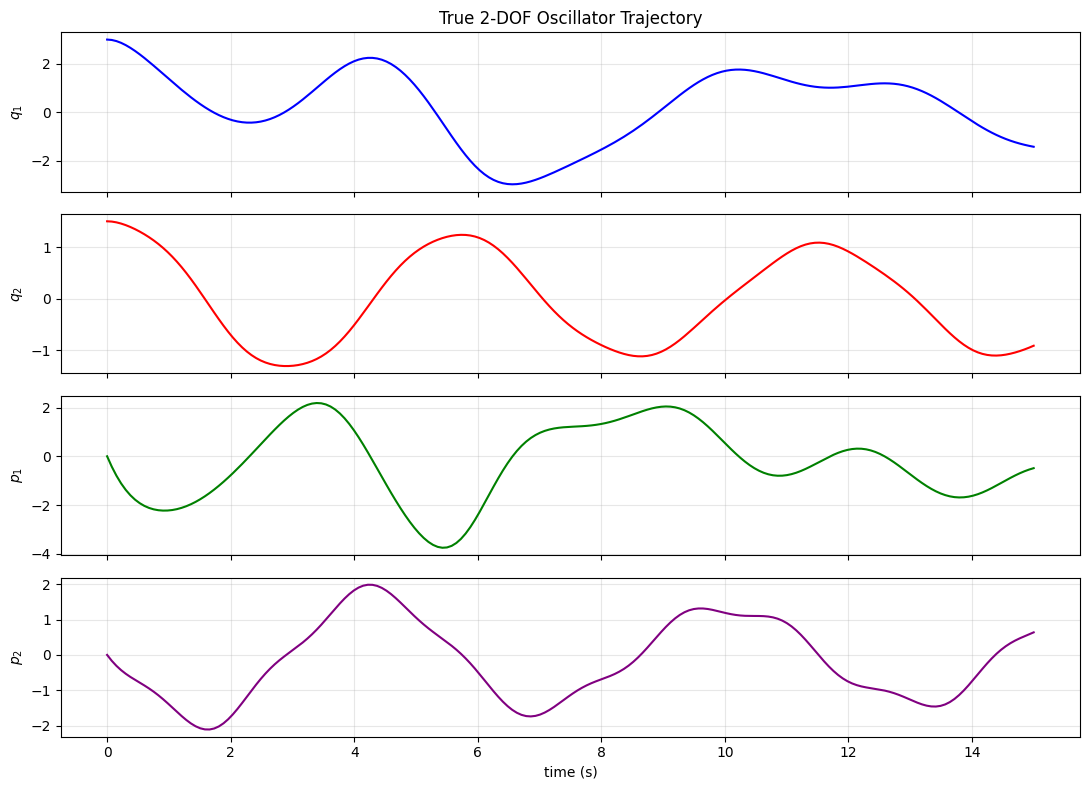

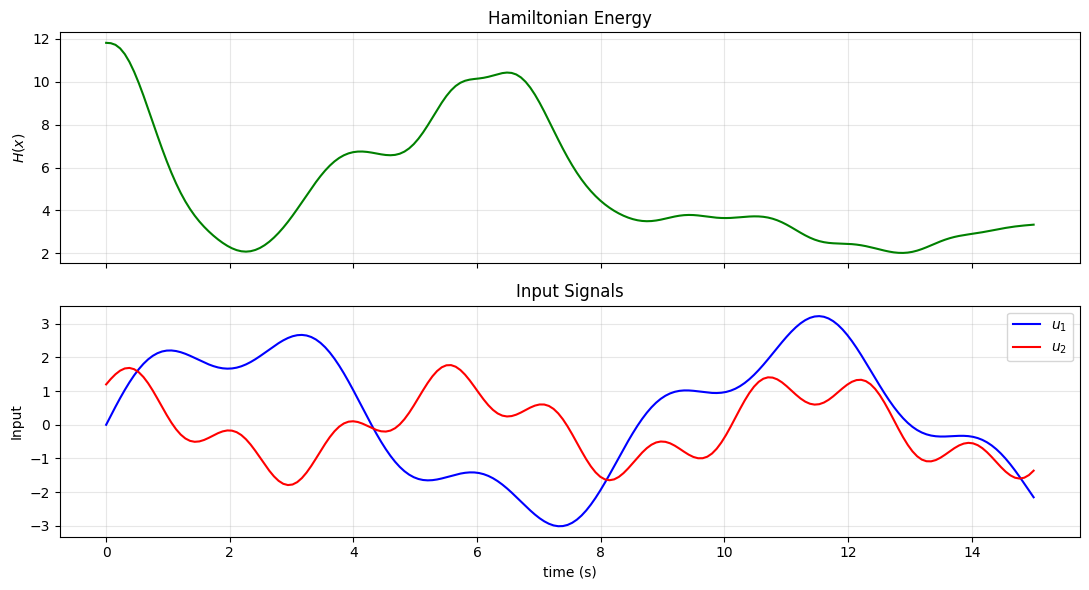

In [4]:
# Plot the large amplitude trajectory (trajectory 1)
x0  = X0_SIM[0]
t_i = np.linspace(0, T_SIM, N_POINTS)
traj_i = odeint(lambda state, t, s=input_signal: dynamics(state, t, s), x0, t_i)
u_i    = np.array([input_signal(t) for t in t_i])
H_i    = np.array([H_true(x[0], x[1], x[2], x[3]) for x in traj_i])

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
labels = [r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$']
colors = ['b', 'r', 'g', 'purple']
for j, (ax, lbl, col) in enumerate(zip(axes, labels, colors)):
    ax.plot(t_i, traj_i[:, j], col, lw=1.5)
    ax.set_ylabel(lbl); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time (s)')
axes[0].set_title('True 2-DOF Oscillator Trajectory')
plt.tight_layout(); plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(t_i, H_i, 'g', lw=1.5)
ax1.set_ylabel(r'$H(x)$'); ax1.grid(True, alpha=0.3)
ax1.set_title('Hamiltonian Energy')
ax2.plot(t_i, u_i[:, 0], 'b', label=r'$u_1$', lw=1.5)
ax2.plot(t_i, u_i[:, 1], 'r', label=r'$u_2$', lw=1.5)
ax2.set_ylabel('Input'); ax2.set_xlabel('time (s)'); ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title('Input Signals')
plt.tight_layout(); plt.show()

## Step 1: Dataset Preparation

### Data Sampling & Dataset Preparation

Simulate trajectories from multiple initial conditions, add sensor noise, and apply GP smoothing to estimate derivatives $\dot{x}$ and their uncertainty $\Delta$. The result is split into train/dev/test DataLoaders ready for training.

In [5]:
# DATA GENERATION
sigs = [input_signal, input_signal_small, input_signal_q2]
trajs, us, t_all = [], [], []
for i, (x0, sig) in enumerate(zip(X0_SIM, sigs)):
    t_i = np.linspace(i * T_SIM, (i + 1) * T_SIM, N_POINTS)
    x_i = odeint(lambda state, t, s=sig: dynamics(state, t, s), x0, t_i)
    u_i = np.array([sig(t) for t in t_i])
    x_noisy_i = x_i + np.random.normal(0, NOISE, x_i.shape)
    trajs.append(x_noisy_i); us.append(u_i); t_all.append(t_i)

# GP SMOOTHER
smoothed, xdots, xdot_vars = [], [], []
for t_i, x_i in zip(t_all, trajs):
    x_s, xd, xdv = gp_smoother.gp_smooth(t_i, x_i)
    smoothed.append(x_s); xdots.append(xd); xdot_vars.append(xdv)

# DATA LOADERS
train_loader, dev_loader, test_loader = dataset.gpphs_data_from_arrays(
    x=np.concatenate(smoothed),
    x_dot=np.concatenate(xdots),
    u=np.concatenate(us),
    x_dot_var=np.concatenate(xdot_vars),
    split_ratio=[75.0, 15.0, 10.0],
    batch_size=len(X0_SIM) * N_POINTS,
)

C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)
C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gpytorch\models\exact_gp.py:299: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


### Plot

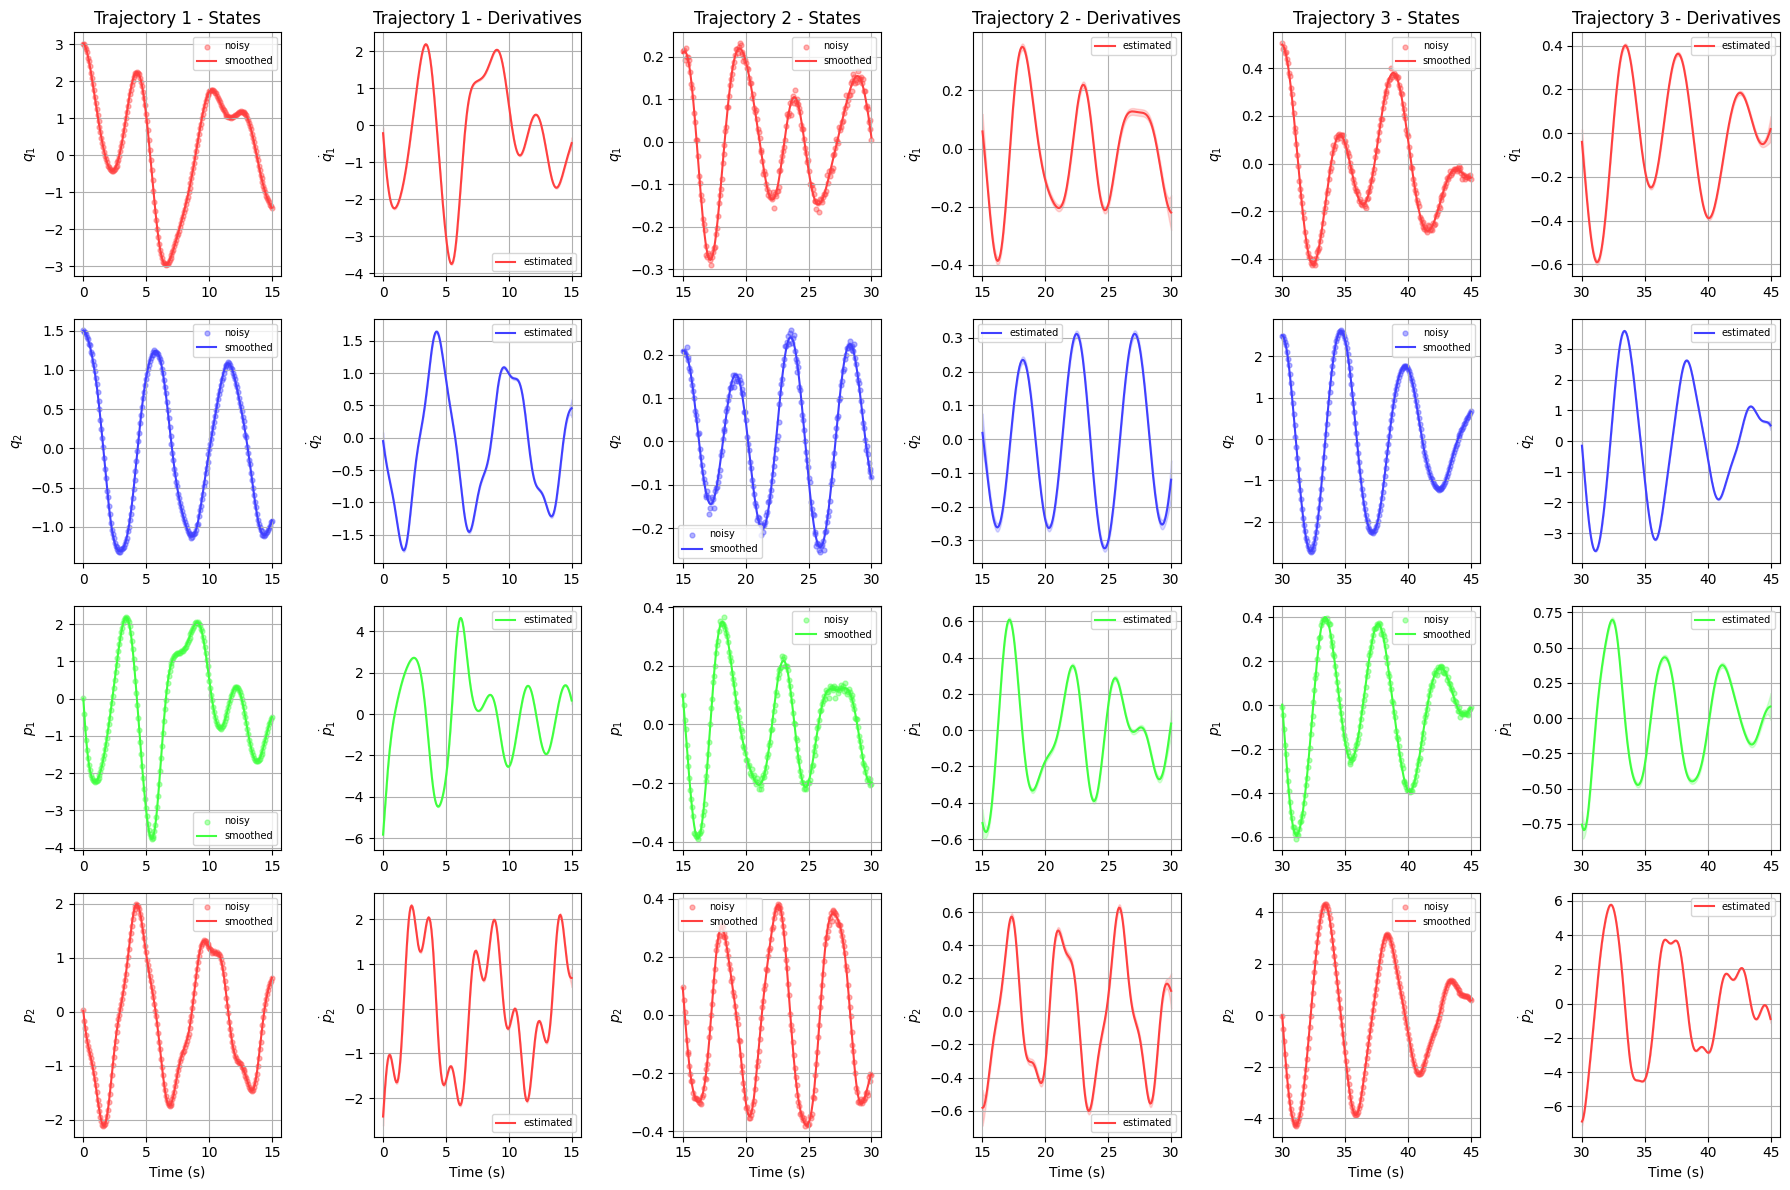

In [6]:
plot.pltGPSmooth(
    t_all,
    trajs,
    smoothed,
    xdots,
    xdot_vars,
    state_lbls=[r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$'],
    deriv_lbls=[r'$\dot{q}_1$', r'$\dot{q}_2$', r'$\dot{p}_1$', r'$\dot{p}_2$'],
)

## Step 2: PHS Structure

Define 7 learnable parameters with appropriate constraints (log parameterization for positivity).

In [7]:
b1    = gp_phs.positive_param('b₁', 0.1)
b2    = gp_phs.positive_param('b₂', 0.1)
b3    = gp_phs.positive_param('b₃', 0.1)
b4    = gp_phs.positive_param('b₄', 0.1)
alpha = gp_phs.nonneg_param('α',   0.1)
beta  = gp_phs.nonneg_param('β',   0.1)
gamma = gp_phs.nonneg_param('γ',   0.1)

### Construct PHSMatrices

In [8]:
phs = gp_phs.PHSMatrices(
    nx=NX, nu=NU,
    J_upper={
        (0, 2): lambda x: torch.ones(x.shape[0]),
        (1, 3): lambda x: torch.ones(x.shape[0]),
        (2, 3): lambda x: gp_phs.recover(alpha) * x[:, 0] * x[:, 1]
    },
    R_diag={
        0: lambda x: torch.zeros(x.shape[0]),
        1: lambda x: torch.zeros(x.shape[0]),
        2: lambda x: (gp_phs.recover(b1) + gp_phs.recover(b2) * x[:, 0]**2) * torch.ones(x.shape[0]),
        3: lambda x: (gp_phs.recover(b3) + gp_phs.recover(b4) * x[:, 1]**2) * torch.ones(x.shape[0])
    },
    G_full={
        (2, 0): lambda x: 1.0 + gp_phs.recover(beta)  * x[:, 0]**2,
        (3, 1): lambda x: 1.0 + gp_phs.recover(gamma) * x[:, 1]**2
    }
)

## Step 3: Build Node, Loss, and Problem

In [9]:
# Build node, loss, and problem
gpphs_module = gp_phs.GPPHSNode(phs, NX, NU)
gpphs_node = Node(gpphs_module, ['X', 'U', 'Xdot', 'Xdot_var'], ['nlml'], name='gp_phs')

# Symbolic variable
nlml = variable('nlml')

# Objective: minimise the negative log marginal likelihood
nlml_loss = nlml.minimize()
nlml_loss.name = 'nlml_loss'

# Aggregate objectives and constraints
objectives = [nlml_loss]
constraints = []

# Loss + problem
loss = PenaltyLoss(objectives, constraints)
problem = Problem([gpphs_node], loss)

print('Problem created with:')
print(f'  {len(list(problem.parameters()))} total parameters')
print(f'  Objectives: {len(objectives)}')
print(f'  Constraints: {len(constraints)}')

Problem created with:
  10 total parameters
  Objectives: 1
  Constraints: 0


## Step 4: Training

In [10]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)
logger    = BasicLogger(args=None, savedir='test', verbosity=1,
                        stdout=['train_loss', 'dev_loss'])
trainer   = Trainer(
    problem,
    train_loader,
    dev_loader,
    optimizer,
    epochs=N_EPOCHS,
    patience=N_EPOCHS,
    train_metric='train_loss',
    dev_metric='dev_loss',
    eval_metric='dev_loss',
    logger=logger,
)

None
Number of parameters: 13


In [ ]:
# train
best_model = trainer.train()
problem.load_state_dict(best_model)

epoch: 0	train_loss: -2781.35449	dev_loss: -206.40277	eltime:  0.38644
epoch: 1	train_loss: -2810.16943	dev_loss: -213.67053	eltime:  0.73405
epoch: 2	train_loss: -2838.70508	dev_loss: -220.91467	eltime:  1.08164
epoch: 3	train_loss: -2866.57910	dev_loss: -228.06104	eltime:  1.44254
epoch: 4	train_loss: -2893.70508	dev_loss: -235.14813	eltime:  1.79746
epoch: 5	train_loss: -2920.40527	dev_loss: -242.13525	eltime:  2.17959
epoch: 6	train_loss: -2945.92725	dev_loss: -249.02539	eltime:  2.52487
epoch: 7	train_loss: -2971.09326	dev_loss: -255.74847	eltime:  2.85314
epoch: 8	train_loss: -2995.68555	dev_loss: -262.31775	eltime:  3.19596
epoch: 9	train_loss: -3019.85010	dev_loss: -268.74756	eltime:  3.53760
epoch: 10	train_loss: -3043.35400	dev_loss: -275.00262	eltime:  3.86889
epoch: 11	train_loss: -3066.58545	dev_loss: -281.17029	eltime:  4.20980
epoch: 12	train_loss: -3089.65771	dev_loss: -287.21881	eltime:  4.64392
epoch: 13	train_loss: -3112.40674	dev_loss: -293.19415	eltime:  5.15756
ep

### Parameter Recovery

In [ ]:
gp_phs.param_table({
    'b₁': (b1, B1_TRUE),
    'b₂': (b2, B2_TRUE),
    'b₃': (b3, B3_TRUE),
    'b₄': (b4, B4_TRUE),
    'α':  (alpha, ALPHA_TRUE),
    'β':  (beta,  BETA_TRUE),
    'γ':  (gamma, GAMMA_TRUE),
})

Parameter  True  Learned  Rel. Error %
       b₁  0.15 0.150283      0.188900
       b₂  0.08 0.080860      1.074880
       b₃  0.12 0.120014      0.012037
       b₄  0.10 0.100196      0.195808
        α  0.05 0.056617     13.233227
        β  0.04 0.042979      7.448082
        γ  0.06 0.060563      0.938016

Mean relative error:   3.30%
Median relative error: 0.94%


,Parameter,True,Learned,Rel. Error %
0,b₁,0.15,0.150283,0.188900
1,b₂,0.08,0.080860,1.074880
2,b₃,0.12,0.120014,0.012037
3,b₄,0.10,0.100196,0.195808
4,α,0.05,0.056617,13.233227
5,β,0.04,0.042979,7.448082
6,γ,0.06,0.060563,0.938016


## Step 5: Hamiltonian Posterior

$H$ is identifiable up to an additive constant; the posterior mean is aligned to the true $H$ at training points.

### Compute posterior

In [ ]:
# BUILD GP POSTERIOR
posterior = gpphs_node.callable.posterior()

# COMPUTE HAMILTONIAN POSTERIOR — trajectory 1 only
H_mean, H_var, H_samples = posterior.predict(
    [smoothed[0]],
    [us[0]],
    [xdots[0]],
    [xdot_vars[0]],
    n_samples=50,
)

# TRUE HAMILTONIAN FOR COMPARISON — trajectory 1 only
x_traj1 = smoothed[0]

H_true_traj1 = np.array([
    H_true(*row) for row in x_traj1
])

### Plot Hamiltonian posterior

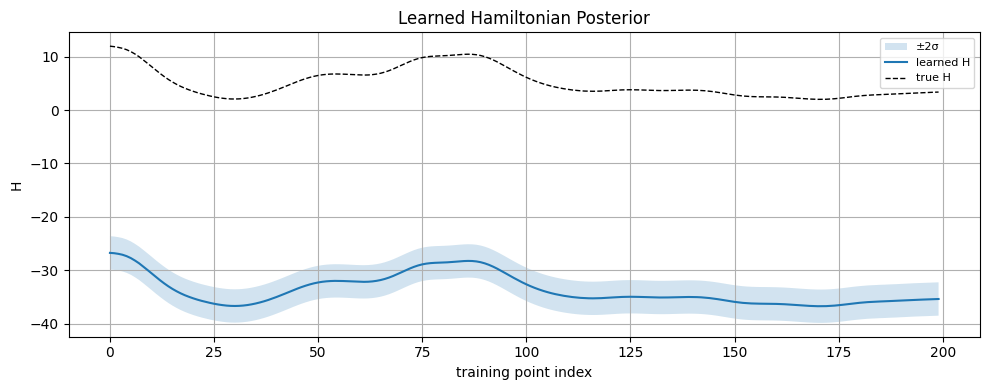

In [ ]:
plot.pltHamiltonian(H_mean.numpy(), H_var.numpy(), H_true=H_true_traj1)

## Step 6: Callable $H^*$ Ensemble

Fit a GP interpolant to each posterior sample so $H^*$ can be evaluated and differentiated anywhere.

In [ ]:
x_traj1_t = torch.tensor(x_traj1, dtype=torch.float32)

ensemble = [
    hamiltonian_approximator.HamiltonianApproximator(
        method='gp',
        lengthscale=posterior.lengthscale,
        signal_var=posterior.signal_var,
    ).fit(x_traj1_t, H_samples[i])
    for i in range(H_samples.shape[0])
]

## Step 7: Derivative Prediction

Verify that the learned model predicts $\dot{x} = (J(x) - R(x))\nabla H^*(x)$ correctly at training points before committing to full trajectory rollout.

In [ ]:
xdot_true = xdots[0]
u_traj1   = us[0]

# EVALUATE LEARNED DYNAMICS: ẋ = (J(x) - R(x))∇H*(x) + G(x)u
JR        = (phs.get_J(x_traj1_t) - phs.get_R(x_traj1_t)).detach().numpy()
G         = phs.get_G(x_traj1_t).detach().numpy()
grad_H    = torch.stack([h.gradient(x_traj1_t) for h in ensemble]).mean(0).detach().numpy()
xdot_pred = np.einsum('nij,nj->ni', JR, grad_H) + np.einsum('nij,nj->ni', G, u_traj1)

### Plot

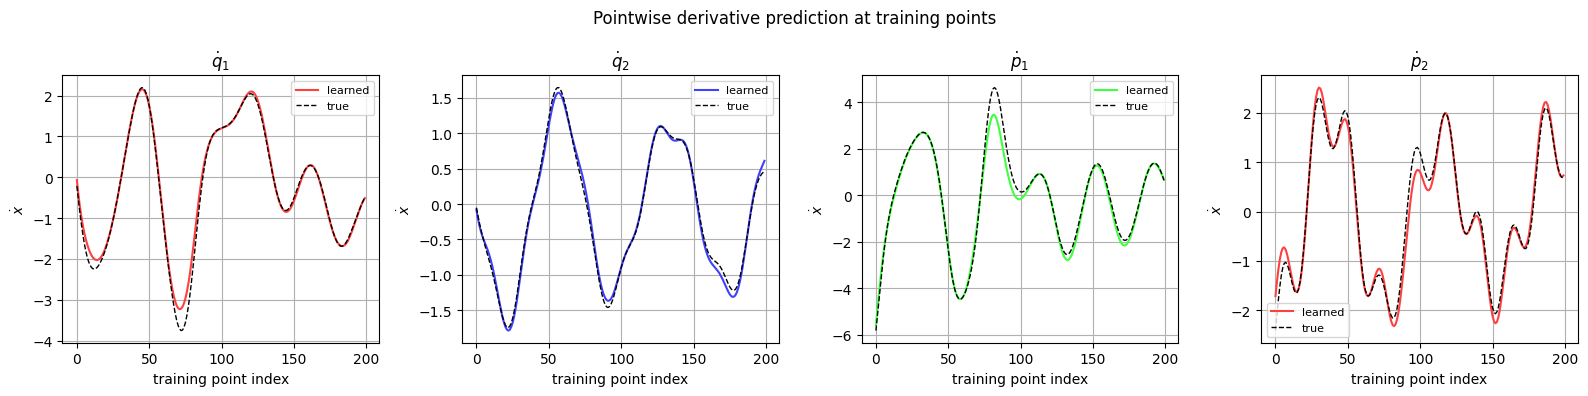

In [ ]:
plot.pltXdot(
    xdot_pred, xdot_true,
    state_lbls=[r'$\dot{q}_1$', r'$\dot{q}_2$', r'$\dot{p}_1$', r'$\dot{p}_2$'],
)

## Step 8: Trajectory Prediction

Simulate 10 trajectories (one per $H^*$ sample). Shaded band = $\pm 2$ std across the ensemble.

In [ ]:
dt    = 0.01
t_sim = np.arange(0.0, T_SIM + dt, dt)

# True reference trajectory
traj_sim = odeint(
    lambda state, t: dynamics(state, t, input_signal),
    X0_SIM[0], t_sim,
)

# Control input: (T, batch=1, nu=1)
u_sim = torch.tensor(
    np.array([input_signal(t) for t in t_sim]),
    dtype=torch.float32,
).unsqueeze(1)

# Simulate learned GP-PHS
phsode = ode.PHSODE(phs, ensemble, NX, NU, method='rk4')
with torch.no_grad():
    result = phsode.simulate(
        x0=torch.tensor(X0_SIM[0:1], dtype=torch.float32),  # (batch=1, nx)
        t_span=(0.0, T_SIM),
        u=u_sim,   # (T, batch=1, nu=1) — time-varying
        dt=dt,
    )

t_gp = result['t_eval'].numpy()
mean = result['mean'][:, 0, :].numpy()   # (T, nx)
std  = result['std'][:, 0, :].numpy()    # (T, nx)

### Plot trajectory prediction

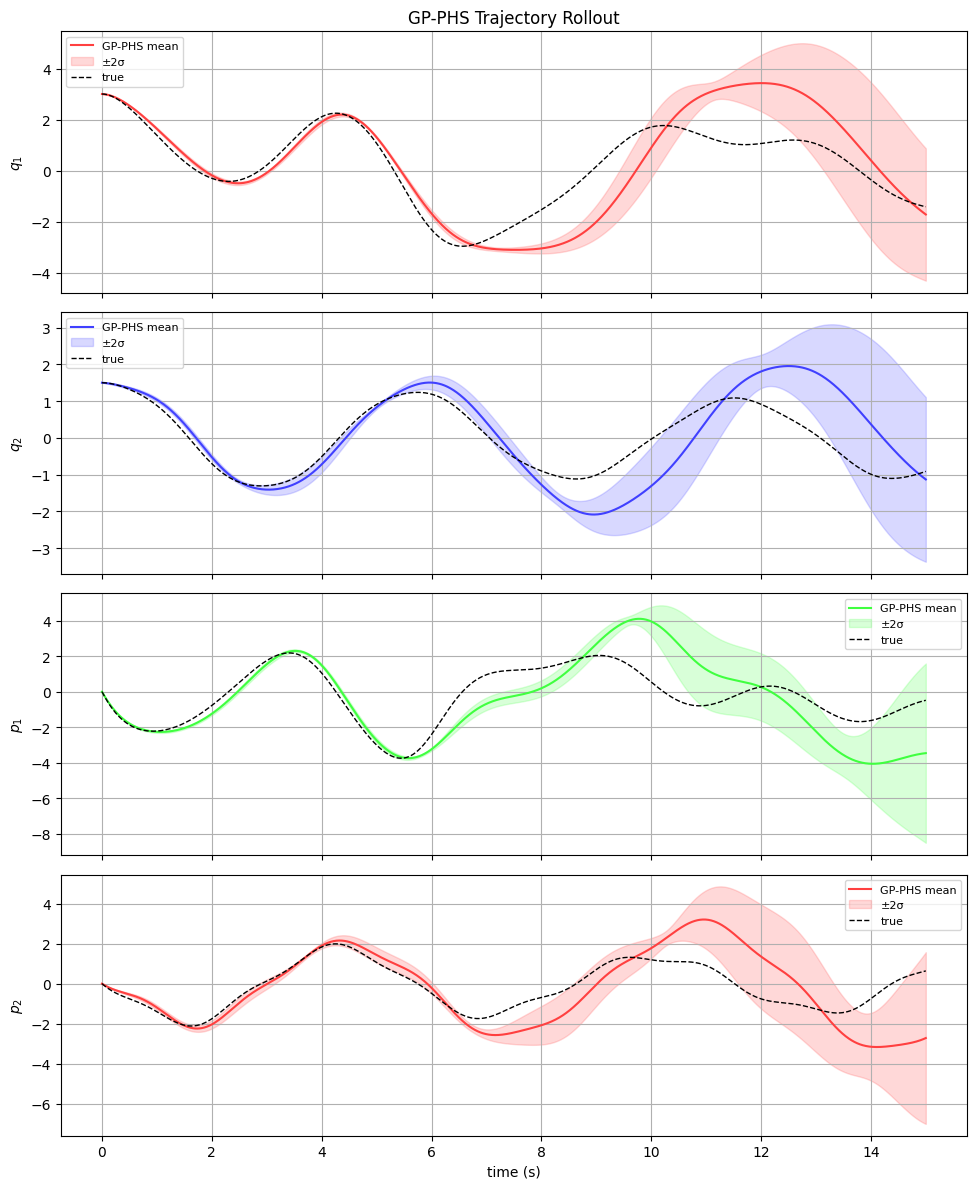

In [ ]:
plot.pltTrajectory(t_gp, mean, std=std, x_true=traj_sim,
                   state_lbls=[r'$q_1$', r'$q_2$', r'$p_1$', r'$p_2$'])